In [2]:
pip install joblib

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install scikit-learn

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --------------- ------------------------ 3.1/8.1 MB 20.6 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.1 MB 15.3 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 15.6 MB/s  0:00:00
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ----- ---------------------------------- 4.7/36.6 MB 25.9 MB/s eta 0:00:02
   --------- ------------------------------ 8.9/36.6 MB 22.2 MB/s eta 0:00:02
   -------------- ------------------------- 12.8/36.6 MB 21.2 MB/s eta 0:00:02
   -------------- ------------------------- 13.4/36.6 MB 20.0 MB/s eta 0:00:02
   --------------- ------------------------ 14.4/36.6 MB 14.6 MB/s eta 0:00:02
   ------------------ --------------------- 17.3/36.6 MB 14.0 MB/s eta 0:00:02
   -------------------- ------------------- 18.6/36.6 MB 13.3 MB/s eta 0:00:02
   ----------

In [14]:
import sys
from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\e16013172\AICC_Preparation\customer-churn-ai")
SRC_PATH = str(PROJECT_ROOT / "src")

if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)
else:
    sys.path.remove(SRC_PATH)
    sys.path.insert(0, SRC_PATH)

# Clear old cached imports from Jupyter
for module in list(sys.modules):
    if module.startswith("churn_prediction"):
        del sys.modules[module]

from churn_prediction.config import TARGET_COLUMN
from churn_prediction.train import train

print("Using TARGET_COLUMN:", TARGET_COLUMN)

best_model = train(
    data_path=PROJECT_ROOT / "data" / "raw" / "E Commerce Dataset.xlsx"
)

best_model.name, best_model.metrics

Using TARGET_COLUMN: Churn


('hist_gradient_boosting',
 {'threshold': 0.33,
  'roc_auc': 0.9991,
  'average_precision': 0.9947,
  'balanced_accuracy': 0.9868,
  'precision_churn': 0.9738,
  'recall_churn': 0.9789,
  'f1_churn': 0.9764,
  'confusion_matrix': [[931, 5], [4, 186]],
  'classification_report': {'0': {'precision': 0.9957219251336898,
    'recall': 0.9946581196581197,
    'f1-score': 0.9951897381079636,
    'support': 936.0},
   '1': {'precision': 0.9738219895287958,
    'recall': 0.9789473684210527,
    'f1-score': 0.9763779527559056,
    'support': 190.0},
   'accuracy': 0.9920071047957372,
   'macro avg': {'precision': 0.9847719573312428,
    'recall': 0.9868027440395861,
    'f1-score': 0.9857838454319345,
    'support': 1126.0},
   'weighted avg': {'precision': 0.9920265541168781,
    'recall': 0.9920071047957372,
    'f1-score': 0.9920154581640107,
    'support': 1126.0}}})

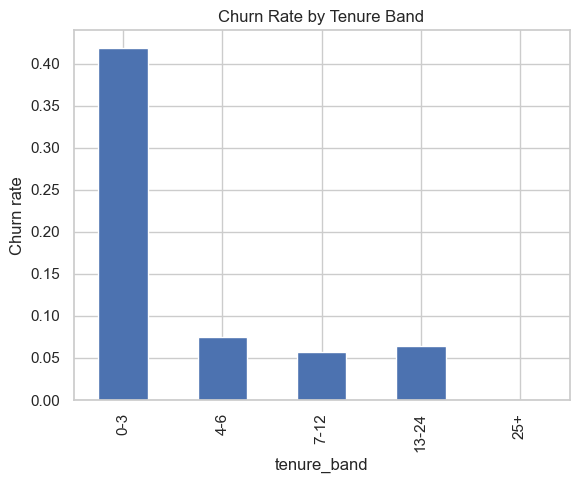

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_excel(r"C:\Users\e16013172\AICC_Preparation\customer-churn-ai\data\raw\E Commerce Dataset.xlsx", sheet_name=1)
df["tenure_band"] = pd.cut(
    df["Tenure"],
    bins=[-1, 3, 6, 12, 24, 60],
    labels=["0-3", "4-6", "7-12", "13-24", "25+"]
)

churn_by_tenure = df.groupby("tenure_band")["Churn"].mean()

churn_by_tenure.plot(kind="bar")
plt.ylabel("Churn rate")
plt.title("Churn Rate by Tenure Band")
plt.show()

In [18]:
import sys
import importlib
from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\e16013172\AICC_Preparation\customer-churn-ai")
SRC_PATH = str(PROJECT_ROOT / "src")

if SRC_PATH in sys.path:
    sys.path.remove(SRC_PATH)

sys.path.insert(0, SRC_PATH)

for module_name in list(sys.modules):
    if module_name.startswith("churn_prediction"):
        del sys.modules[module_name]

import churn_prediction.train as train_module
importlib.reload(train_module)

print(train_module.__file__)
print(hasattr(train_module, "train_without_tenure"))

C:\Users\e16013172\AICC_Preparation\customer-churn-ai\src\churn_prediction\train.py
True


In [19]:
from churn_prediction.train import train_without_tenure

best_without_tenure = train_without_tenure(
    data_path=PROJECT_ROOT / "data" / "raw" / "E Commerce Dataset.xlsx"
)

best_without_tenure.name, best_without_tenure.metrics

('hist_gradient_boosting',
 {'threshold': 0.39,
  'roc_auc': 0.9883,
  'average_precision': 0.9648,
  'balanced_accuracy': 0.9357,
  'precision_churn': 0.9333,
  'recall_churn': 0.8842,
  'f1_churn': 0.9081,
  'confusion_matrix': [[924, 12], [22, 168]],
  'classification_report': {'0': {'precision': 0.9767441860465116,
    'recall': 0.9871794871794872,
    'f1-score': 0.9819341126461212,
    'support': 936.0},
   '1': {'precision': 0.9333333333333333,
    'recall': 0.8842105263157894,
    'f1-score': 0.9081081081081082,
    'support': 190.0},
   'accuracy': 0.9698046181172292,
   'macro avg': {'precision': 0.9550387596899225,
    'recall': 0.9356950067476384,
    'f1-score': 0.9450211103771147,
    'support': 1126.0},
   'weighted avg': {'precision': 0.9694190865656022,
    'recall': 0.9698046181172292,
    'f1-score': 0.9694767939407728,
    'support': 1126.0}}})